In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import linear_model

In [2]:
df=pd.read_csv('canada_per_capita_income.csv')
df.head()

,year,per capita income (US$)
0,1970,3399.299037
1,1971,3768.297935
2,1972,4251.175484
3,1973,4804.463248
4,1974,5576.514583


In [5]:
df.shape

(47, 2)

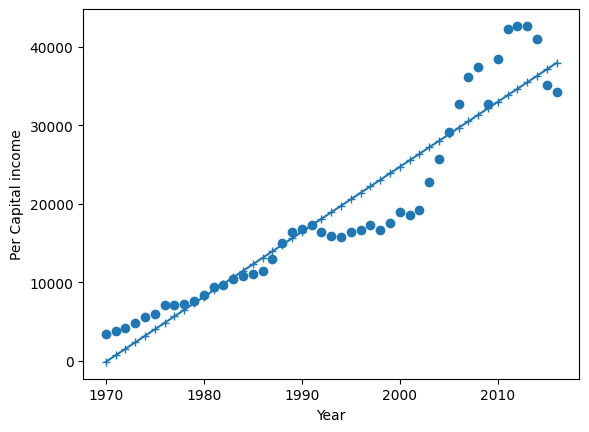

In [11]:
%matplotlib inline
plt.scatter(df.year,df['per capita income (US$)'])
plt.plot(df.year,reg.predict(df[['year']]),marker='+')
plt.xlabel('Year')
plt.ylabel('Per Capital income')
plt.show()

In [7]:
reg=linear_model.LinearRegression()
reg.fit(df[['year']],df['per capita income (US$)'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [8]:
reg.intercept_

np.float64(-1632210.7578554575)

In [12]:
reg.predict([[2030]])

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([49573.34484664])

## 2. Multivariables

In [1]:
pip install word2number

Defaulting to user installation because normal site-packages is not writeable
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for word2number: filename=word2number-1.1-py3-none-any.whl size=5680 sha256=0ca3129dabe771717a6bf28650314139756a934077486fb561349d9ac1a590a3
  Stored in directory: c:\users\user\appdata\local\pip\cache\wheels\aa\2b\71\ede4a3c3520a8374778c16c345e0e78e25d1ffe38f4c5c1e8a
Successfully built word2number
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [13]:
df_hir=pd.read_csv('Datasets/hiring.csv')
df_hir.head()

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,five,6.0,7,60000
3,two,10.0,10,65000
4,seven,9.0,6,70000


In [14]:
print(len(df_hir['experience']))

8


In [15]:
df_hir['experience']=df_hir['experience'].apply(lambda x: w2n.word_to_num(x) if isinstance(
    x,str) else x)
df_hir.head()


,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,NaN,8.0,9,50000
1,NaN,8.0,6,45000
2,5.0,6.0,7,60000
3,2.0,10.0,10,65000
4,7.0,9.0,6,70000


In [16]:
df_hir['experience'].fillna(0,inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_10836\956710888.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_hir['experience'].fillna(0,inplace=True)


In [17]:
df_hir.head()

,experience,test_score(out of 10),interview_score(out of 10),salary($)
0,0.0,8.0,9,50000
1,0.0,8.0,6,45000
2,5.0,6.0,7,60000
3,2.0,10.0,10,65000
4,7.0,9.0,6,70000


In [19]:
df_hir.isnull().sum()

experience                    0
test_score(out of 10)         1
interview_score(out of 10)    0
salary($)                     0
dtype: int64

<Axes: title={'center': 'score dist'}, ylabel='Density'>

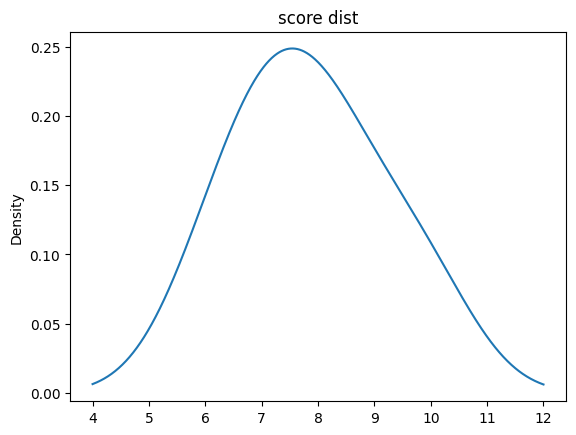

In [21]:
df_hir['test_score(out of 10)'].plot(kind='kde',title='score dist')

In [25]:
#lets use mean then since dist is quite normal
df_hir['test_score(out of 10)'].fillna(df_hir['test_score(out of 10)'].mean(),inplace=True)
df_hir.tail()

,experience,test_score(out of 10),interview_score(out of 10),salary($)
3,2.0,10.000000,10,65000
4,7.0,9.000000,6,70000
5,3.0,7.000000,10,62000
6,10.0,7.857143,7,72000
7,11.0,7.000000,8,80000


In [26]:
df_hir.isnull().sum()

experience                    0
test_score(out of 10)         0
interview_score(out of 10)    0
salary($)                     0
dtype: int64

In [27]:
#lets check the important variables
df_hir.corr(numeric_only=True)

,experience,test_score(out of 10),interview_score(out of 10),salary($)
experience,1.000000,-0.241897,-0.29048,0.908017
test_score(out of 10),-0.241897,1.000000,0.13971,-0.002850
interview_score(out of 10),-0.290480,0.139710,1.00000,0.037820
salary($),0.908017,-0.002850,0.03782,1.000000


In [28]:
reg=linear_model.LinearRegression()
reg.fit(df_hir[['experience','test_score(out of 10)','interview_score(out of 10)']],df_hir['salary($)'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [29]:
reg.coef_

array([2827.63404314, 1912.93803053, 2196.9753141 ])

In [30]:
reg.intercept_

np.float64(17237.330313727172)

In [31]:
reg.predict([[2,9,6],[12,10,10]])

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([53290.89255945, 92268.07227784])

In [33]:
reg.predict([[7,9,6]])

C:\Users\user\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([67429.06277517])

model underestimates